# YAPPERS — BI10 Round 01: toàn bộ phân tích (Task 1 → 5)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thanh-tai-435/BI10GroupYAPPERS/blob/main/notebooks/full_pipeline.ipynb)

**Cách chạy:** `Runtime → Run all` (~3–5 phút). Không cần cài thư viện. Kết quả: số liệu từng task + chart trong `outputs/figures/`, cuối notebook có nút tải toàn bộ chart (zip).

**Cần 1 GitHub token (repo private)** — làm 1 lần:
1. Đăng nhập GitHub bằng tài khoản **đã được mời vào repo** `thanh-tai-435/BI10GroupYAPPERS` (chấp nhận lời mời trong email/thông báo trước).
2. Vào https://github.com/settings/tokens/new (Settings → Developer settings → Personal access tokens → **Tokens (classic)** → Generate new token (classic)).
3. *Note*: `colab-yappers` · *Expiration*: 7 days · tick scope **`repo`** → **Generate token** → copy chuỗi `ghp_...` (chỉ hiện 1 lần).
4. Trong Colab: icon 🔑 **Secrets** ở thanh trái → **Add new secret** → Name `GH_TOKEN`, Value = token → bật **Notebook access**.
   *(Bỏ qua bước 4 cũng được: cell SETUP sẽ hiện ô cho bạn dán token.)*

> Không dùng token *Fine-grained*: loại này không truy cập được repo cá nhân của người khác khi bạn chỉ là collaborator. Không dán token vào code/cell — token nằm trong Secrets nên share notebook không lộ.

**3 luật:** (1) Wellbeing, KHÔNG credit scoring. (2) So bằng tỷ lệ, không so VND tuyệt đối. (3) Mỗi nhận định có số hoặc chart.

In [2]:
#@title ⚙️ SETUP — chạy 1 lần mỗi phiên Colab (không cần pip install gì cả)
# Colab có sẵn pandas / numpy / scikit-learn / matplotlib / openpyxl -> đủ cho mọi script trong draft/.
import os, re, sys, gzip, shutil, urllib.request
REPO = "/content/BI10GroupYAPPERS"
# Data tải thẳng từ thư mục Drive public (anyone with link) — không cần mount Drive / Add shortcut
# Thư mục: https://drive.google.com/drive/folders/1gOqCyY9IfFUJtbr2r3vR_Z3t61O71CrC
URL = {
    "consumer_financial_health_engagement_2025.csv": "https://drive.google.com/file/d/1YyueAH9Kasid6V_obml9pCMwh2dB0ryn/view",
    "consumer_transactions_2025.parquet.gz":         "https://drive.google.com/file/d/1O33KpFbUx6_BRGwFTb80xVSB3tzXqt5H/view",
    "data_dictionary.xlsx":                          "https://drive.google.com/file/d/1nFlZHmuaoK8VQ5xqRN2f4ZLqoR3gk2j1/view",
}

from google.colab import userdata

if os.path.exists(REPO):
    os.system(f"git -C {REPO} pull -q")
else:
    try:
        tok = userdata.get("GH_TOKEN")   # 🔑 Secrets bên trái: tên GH_TOKEN, bật "Notebook access"
    except Exception:                    # chưa tạo secret -> hỏi trực tiếp (không lưu vào notebook)
        from getpass import getpass
        tok = getpass("Chưa có secret GH_TOKEN — dán GitHub token (ghp_...) rồi Enter: ").strip()
    os.system(f"git clone -q https://{tok}@github.com/thanh-tai-435/BI10GroupYAPPERS.git {REPO}")
assert os.path.exists(REPO), "Clone thất bại: kiểm tra GH_TOKEN + đã được mời vào repo chưa"
os.chdir(REPO)

# Dựng lại đúng đường dẫn mà các script draft/*.py đang dùng
D = "BI10_ROUND01_DATASET"
TX = f"{D}/consumer_transactions_2025.parquet/consumer_transactions_2025.csv"
os.makedirs(os.path.dirname(TX), exist_ok=True)
for f, u in URL.items():
    if not os.path.exists(f"{D}/{f}"):
        fid = re.search(r"/d/([\w-]+)", u).group(1)   # tải file public bằng stdlib, không cần gdown
        urllib.request.urlretrieve(f"https://drive.usercontent.google.com/download?id={fid}&export=download&confirm=t", f"{D}/{f}")
if not os.path.exists(TX):   # .parquet.gz thực chất là CSV giao dịch nén gzip (134MB -> 597MB, ~30s)
    with gzip.open(f"{D}/consumer_transactions_2025.parquet.gz") as src, open(TX, "wb") as dst:
        shutil.copyfileobj(src, dst)

# Script gốc gọi sys.stdout.reconfigure(); stdout của Colab không có hàm này -> cho thành no-op
if not hasattr(sys.stdout, "reconfigure"):
    type(sys.stdout).reconfigure = lambda self, **k: None
os.makedirs("outputs/figures", exist_ok=True)
if not os.path.exists("draft/task4_features.csv"):   # nhãn segment (git-ignore) — task3/task5/charts cần
    os.system("python draft/task4.py > /dev/null")
print("✅ Sẵn sàng — cwd:", os.getcwd())


✅ Sẵn sàng — cwd: /content/BI10GroupYAPPERS


---
# Task 1 — Exploratory Data Analysis
### 1.0 Script gốc `draft/task1_eda.py`

In [3]:
%run -i draft/task1_eda.py


Q1 - Peak vs trough month: driver = count or ticket?
                            sum   count  avg_ticket  pct_annual
transaction_month                                              
1                  185570433000  104727   1771945.0         6.0
2                  174365111000   97657   1785485.0         5.0
3                  254750003000  143789   1771693.0         8.0
4                  236320934000  134970   1750915.0         7.0
5                  257623444000  146875   1754032.0         8.0
6                  305572891000  173869   1757489.0         9.0
7                  299556013000  172444   1737121.0         9.0
8                  304519084000  176118   1729063.0         9.0
9                  246520864000  140185   1758540.0         8.0
10                 243005639000  138106   1759559.0         7.0
11                 248795833000  143056   1739150.0         8.0
12                 488032709000  280598   1739259.0        15.0

Annual total spend: 3.24T VND
PEAK  month 12: 488

### 1.1 Phân tích làm sâu `draft/task1_deep.py`

In [4]:
# Style chung cho chart (giống draft/make_charts.py)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 250, "display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})
C = dict(primary="#2E5EAA", accent="#E4572E", good="#3C9D6E", warn="#E0A32E", muted="#9AA5B1", ink="#22303F")
os.makedirs("outputs/figures", exist_ok=True)
def save(fig, name):
    fig.tight_layout(); fig.savefig(f"outputs/figures/{name}", dpi=150, bbox_inches="tight"); plt.show(); print("saved", name)
def h(t): print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)
# cột bổ sung cho Q1/Q4 (task1_eda.py chỉ nạp 6 cột)
tx2 = pd.read_csv(TXN, usecols=["consumer_id", "activity_datetime", "spending_category", "transaction_month"])



DEEP Q3 - Channel breakdown for high-spend, below-average-digital provinces
Share of TRANSACTIONS by channel (%):
 transaction_channel   POS  QR Payment  E-commerce  Mobile App  Recurring Payment
province_city                                                                   
Hà Nội               59.1        19.9         8.5         7.6                4.9
Đồng Nai             59.3        19.8         8.5         7.6                4.8
Lâm Đồng             58.9        19.7         8.7         7.6                5.1
Hưng Yên             59.2        19.8         8.4         7.4                5.1
Hải Phòng            59.2        20.1         8.5         7.4                4.9
National             58.8        19.8         8.7         7.7                4.9

Share of SPEND VALUE by channel (%):
 transaction_channel   POS  QR Payment  E-commerce  Mobile App  Recurring Payment
province_city                                                                   
Hà Nội               59.1        19

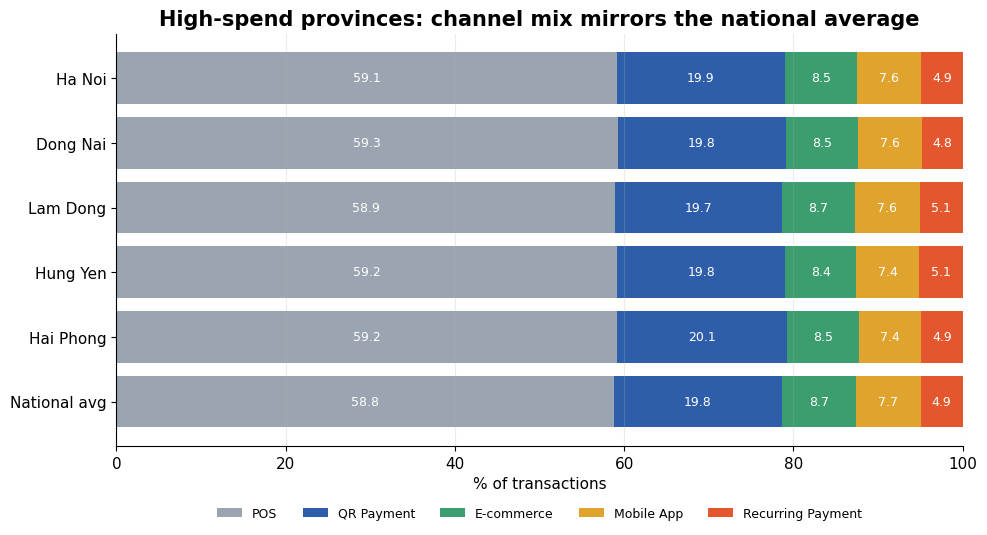

saved t1_province_channel.png


In [5]:
h("DEEP Q3 - Channel breakdown for high-spend, below-average-digital provinces")
CH = ["POS", "QR Payment", "E-commerce", "Mobile App", "Recurring Payment"]
top = target.head(5)["province_city"].tolist()
sub = txn[txn.province_city.isin(top)]
cnt = pd.crosstab(sub.province_city, sub.transaction_channel, normalize="index")[CH] * 100
val = pd.crosstab(sub.province_city, sub.transaction_channel, values=sub.spend_amount_vnd, aggfunc="sum", normalize="index")[CH] * 100
nat_c = txn.transaction_channel.value_counts(normalize=True)[CH] * 100
nat_v = txn.groupby("transaction_channel").spend_amount_vnd.sum()[CH] / txn.spend_amount_vnd.sum() * 100
cnt.loc["National"], val.loc["National"] = nat_c, nat_v
cnt, val = cnt.loc[top + ["National"]], val.loc[top + ["National"]]
print("Share of TRANSACTIONS by channel (%):\n", cnt.round(1).to_string())
print("\nShare of SPEND VALUE by channel (%):\n", val.round(1).to_string())
gap = (cnt.drop("National")[CH[1:]].sum(1) - cnt.loc["National", CH[1:]].sum()).round(2)
print("\nDigital-share gap vs national (pp, by count):\n", gap.to_string())
print(f"-> max |gap| = {gap.abs().max():.2f}pp: channel mix is near-identical; digital value share "
      f"{val.drop('National')[CH[1:]].sum(1).min():.1f}-{val.drop('National')[CH[1:]].sum(1).max():.1f}% vs national {val.loc['National', CH[1:]].sum():.1f}%")

EN = {"Thành phố Hồ Chí Minh": "Ho Chi Minh City", "Hà Nội": "Ha Noi", "Đồng Nai": "Dong Nai", "Lâm Đồng": "Lam Dong",
      "Hưng Yên": "Hung Yen", "Hải Phòng": "Hai Phong", "Cần Thơ": "Can Tho", "Đà Nẵng": "Da Nang", "National": "National avg"}
fig, ax = plt.subplots(figsize=(10, 5.5))
cols = [C["muted"], C["primary"], C["good"], C["warn"], C["accent"]]
left = np.zeros(len(cnt))
for ch, col in zip(CH, cols):
    ax.barh([EN.get(p, p) for p in cnt.index], cnt[ch], left=left, color=col, label=ch)
    for i, v in enumerate(cnt[ch]):
        if v > 4: ax.text(left[i] + v / 2, i, f"{v:.1f}", ha="center", va="center", color="white", fontsize=9)
    left += cnt[ch].values
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel("% of transactions"); ax.grid(axis="y", visible=False)
ax.set_title("High-spend provinces: channel mix mirrors the national average")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(.5, -.12), frameon=False, fontsize=9)
save(fig, "t1_province_channel.png")



DEEP Q2 - Is the essential->discretionary inversion a gradient or a threshold artefact?
         months  discretionary_pct
fhs_bin                           
<40        95.0               71.6
40-49     429.0               64.2
50-59    2028.0               57.3
60-69    4060.0               54.4
70-79    3905.0               49.2
80-89     474.0               40.6
90+         1.0               17.4


/tmp/ipykernel_4019/4111483251.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gb = mon.groupby("fhs_bin", observed=True).apply(lambda d: pd.Series({


Spearman(FHS, discretionary_spend_ratio) month grain: -0.474
  FHS<35 (   55 mo)  73.5% discretionary  vs  FHS>=85 (   36 mo)  30.2%  -> gap +43.3pp
  FHS<40 (   95 mo)  71.6% discretionary  vs  FHS>=80 (  475 mo)  40.5%  -> gap +31.1pp
  FHS<45 (  176 mo)  68.7% discretionary  vs  FHS>=75 ( 1964 mo)  45.6%  -> gap +23.1pp
  FHS<50 (  524 mo)  65.4% discretionary  vs  FHS>=70 ( 4380 mo)  48.7%  -> gap +16.7pp


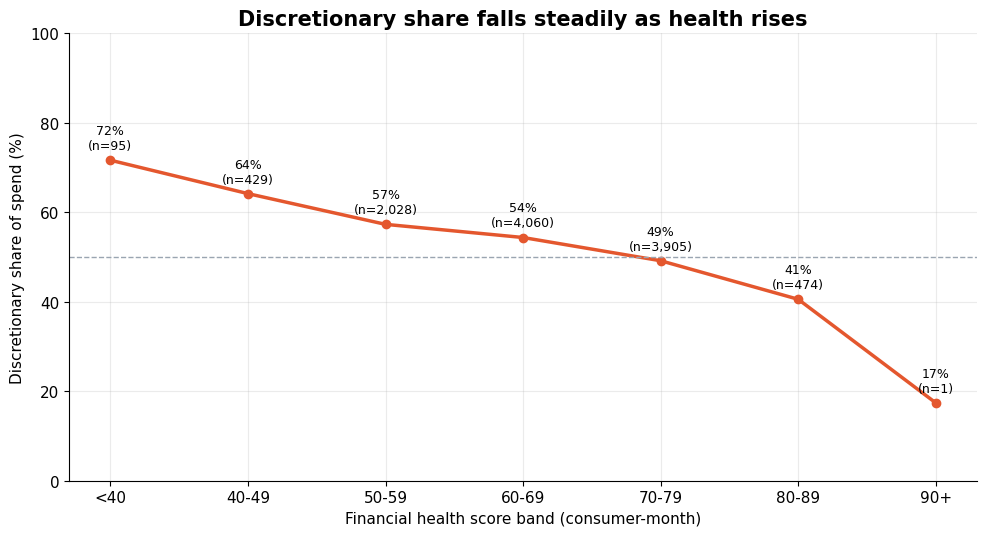

saved t1_discretionary_gradient.png


In [6]:
h("DEEP Q2 - Is the essential->discretionary inversion a gradient or a threshold artefact?")
mon["fhs_bin"] = pd.cut(mon.financial_health_score, [0, 40, 50, 60, 70, 80, 90, 101], right=False,
                        labels=["<40", "40-49", "50-59", "60-69", "70-79", "80-89", "90+"])
gb = mon.groupby("fhs_bin", observed=True).apply(lambda d: pd.Series({
    "months": len(d), "discretionary_pct": 100 * d.discretionary_spend_vnd.sum() / (d.essential_spend_vnd.sum() + d.discretionary_spend_vnd.sum())}))
print(gb.round(1).to_string())
print(f"Spearman(FHS, discretionary_spend_ratio) month grain: "
      f"{mon.financial_health_score.corr(mon.discretionary_spend_ratio, method='spearman'):+.3f}")
for lo, hi in [(35, 85), (40, 80), (45, 75), (50, 70)]:
    a, b = mon[mon.financial_health_score < lo], mon[mon.financial_health_score >= hi]
    da = 100 * a.discretionary_spend_vnd.sum() / (a.essential_spend_vnd.sum() + a.discretionary_spend_vnd.sum())
    db = 100 * b.discretionary_spend_vnd.sum() / (b.essential_spend_vnd.sum() + b.discretionary_spend_vnd.sum())
    print(f"  FHS<{lo} ({len(a):>5} mo) {da:5.1f}% discretionary  vs  FHS>={hi} ({len(b):>5} mo) {db:5.1f}%  -> gap {da-db:+.1f}pp")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(gb.index.astype(str), gb.discretionary_pct, marker="o", lw=2.5, color=C["accent"])
for x, y, n in zip(gb.index.astype(str), gb.discretionary_pct, gb.months):
    ax.annotate(f"{y:.0f}%\n(n={int(n):,})", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.axhline(50, color=C["muted"], ls="--", lw=1); ax.set_ylim(0, 100)
ax.set_xlabel("Financial health score band (consumer-month)"); ax.set_ylabel("Discretionary share of spend (%)")
ax.set_title("Discretionary share falls steadily as health rises")
save(fig, "t1_discretionary_gradient.png")


In [7]:
h("DEEP Q1 - Which categories drive the December peak? + timestamp-year check")
g = tx2.groupby(["transaction_month", "spending_category"]).size().unstack(fill_value=0)
inc = (g.loc[12] - g.loc[2]).sort_values(ascending=False)
print(f"Dec - Feb transaction count, total increase {inc.sum():,}:")
print(pd.DataFrame({"increase": inc, "share_of_increase_%": (100 * inc / inc.sum()).round(1),
                    "growth_%": (100 * (g.loc[12] / g.loc[2] - 1)).round(0)}).head(14).to_string())
yr = pd.to_datetime(tx2.activity_datetime).dt.year.value_counts().sort_index()
print("\nactivity_datetime years:\n", yr.to_string())
dec = pd.to_datetime(tx2.loc[tx2.transaction_month == 12, "activity_datetime"]).dt.year.value_counts().sort_index()
print("December rows by year:\n", dec.to_string())



DEEP Q1 - Which categories drive the December peak? + timestamp-year check
Dec - Feb transaction count, total increase 182,941:
                                  increase  share_of_increase_%  growth_%
spending_category                                                        
Chăm sóc cá nhân                     12962                  7.1     190.0
Du lịch                               5742                  3.1     188.0
Dịch vụ trực tuyến khác               8941                  4.9     191.0
Giải trí                             13361                  7.3     191.0
Mua sắm khác tại cửa hàng            11499                  6.3     192.0
Mua sắm trực tuyến                   13834                  7.6     189.0
Mua sắm tại cửa hàng                 16535                  9.0     186.0
Nhà cửa và tiện ích                  17585                  9.6     193.0
Siêu thị và tạp hóa tại cửa hàng     17053                  9.3     181.0
Sức khỏe và thể thao                 11974               

In [8]:
h("DEEP Q4 - Reach & habit of the two top categories")
top_cnt_cat, top_spend_cat = cat["count"].idxmax(), cat["sum"].idxmax()
nmon = tx2.groupby("consumer_id").transaction_month.nunique()
for c_ in [top_cnt_cat, top_spend_cat]:
    s = tx2[tx2.spending_category == c_]
    buyers = s.consumer_id.nunique()
    per = s.groupby(["consumer_id", "transaction_month"]).size()
    print(f"{c_}: {buyers}/999 consumers buy it ({100*buyers/999:.1f}%) | "
          f"{per.mean():.1f} purchases per buyer-month | active in {s.groupby('consumer_id').transaction_month.nunique().mean():.1f} months/yr")



DEEP Q4 - Reach & habit of the two top categories
Xăng dầu và di chuyển: 967/999 consumers buy it (96.8%) | 17.3 purchases per buyer-month | active in 11.2 months/yr
Siêu thị và tạp hóa tại cửa hàng: 992/999 consumers buy it (99.3%) | 16.1 purchases per buyer-month | active in 11.0 months/yr


In [9]:
h("DEEP Q5 - Bootstrap 95% CI of mean FHS per age cohort (consumer level, all 999 incl. 7 minors)")
cons1 = mon.groupby("consumer_id").agg(fhs=("financial_health_score", "mean"), age=("age", "first"))
cons1["cohort"] = pd.cut(cons1.age, bins=bins, labels=labels)
rng = np.random.default_rng(42)
rows = []
for k, s in cons1.groupby("cohort", observed=True).fhs:
    bs = [rng.choice(s.values, len(s)).mean() for _ in range(1000)]
    rows.append((k, len(s), s.mean(), *np.percentile(bs, [2.5, 97.5])))
ci = pd.DataFrame(rows, columns=["cohort", "n", "mean_fhs", "ci_lo", "ci_hi"]).set_index("cohort")
print(ci.round(2).to_string())
lo_max, hi_min = ci.ci_lo.max(), ci.ci_hi.min()
print(f"All CIs overlap: {bool(lo_max <= hi_min)} (max lower {lo_max:.2f} vs min upper {hi_min:.2f})")
ci.to_csv("draft/task1_age_ci.csv")   # P2 dùng chung
assert ci.n.sum() == 999



DEEP Q5 - Bootstrap 95% CI of mean FHS per age cohort (consumer level, all 999 incl. 7 minors)
          n  mean_fhs  ci_lo  ci_hi
cohort                             
15-24    69     65.75  64.73  66.74
25-34   177     65.79  65.09  66.43
35-44   165     66.44  65.83  67.09
45-54   198     65.98  65.34  66.61
55-64   175     66.97  66.35  67.60
65+     215     66.56  65.83  67.26
All CIs overlap: True (max lower 66.35 vs min upper 66.43)


In [10]:
h("Slide 4 dataset check")
print(f"consumer-months {len(mon):,} | consumers {mon.consumer_id.nunique()} | transactions {len(txn):,} | "
      f"min age {mon.age.min()} | minors {mon.loc[mon.age < 18].consumer_id.nunique()}")
assert (len(mon), mon.consumer_id.nunique(), len(txn)) == (10992, 999, 1852394)



Slide 4 dataset check
consumer-months 10,992 | consumers 999 | transactions 1,852,394 | min age 15 | minors 7


**Findings:**
- Q3: 5 tỉnh chi nhiều nhưng digital thấp hơn TB (Hà Nội, Đồng Nai, Lâm Đồng, Hưng Yên, Hải Phòng) lệch tối đa **0.46pp** so với toàn quốc; POS 58.9–59.3% vs 58.8% → địa lý không phải đòn bẩy.
- Q2: tỷ trọng discretionary giảm đều theo FHS: **71.6% (<40) → 64.2 → 57.3 → 54.4 → 49.2 → 40.6% (80–89)**; ngưỡng nào cũng giữ chiều (FHS<35 vs ≥85: 73.5% vs 30.2%) → đảo chiều là một độ dốc, không do ngưỡng.
- Q1: T12 tăng **đồng đều ở cả 14 category (+181–193%)**, không category nào dẫn dắt; 100% timestamp là năm 2025 → bỏ caveat 'gộp 2 năm', thay bằng 'mức tăng đồng đều giống hệ số mùa vụ của dữ liệu tổng hợp'.
- Q4: Fuel được **96.8%** khách mua, 17.3 lần/khách-tháng; Groceries **99.3%**, 16.1 lần → cả hai là thói quen gần như toàn dân.
- Q5: CI 95% FHS của 6 nhóm tuổi **chồng nhau** (65.75–66.97) → tuổi không phân biệt được sức khoẻ tài chính. Bảng CI lưu ở draft/task1_age_ci.csv cho P2.

---
# Task 2 — Financial Health
### 2.0 Script gốc `draft/task2.py`

In [11]:
%run -i draft/task2.py


Q1 - Distribution of financial_health_score
CONSUMER LEVEL (n=999, mean of each consumer's months)
  mean 66.30 | median 66.24 | std 4.67 | min 42.32 | max 80.83
  IQR 63.40-69.28 | skew -0.315 (neg = left tail of low-health)
    p5  = 58.61
    p10 = 60.85
    p25 = 63.40
    p50 = 66.24
    p75 = 69.28
    p90 = 72.21
    p95 = 73.91

MONTH LEVEL (n=10992 consumer-months)
  mean 66.37 | median 67.70 | std 9.48 | min 0.80 | max 90.20
  month-to-month mean FHS:
month
1     71.72
2     73.63
3     67.28
4     68.70
5     66.93
6     63.30
7     63.79
8     63.30
9     67.74
10    68.18
11    67.53
12    54.25

Segment shares (financial_health_segment, consumer-months):
  Ổn định                               7,965 ( 72.5%)
  Cần theo dõi                          2,457 ( 22.4%)
  Khỏe mạnh                               475 (  4.3%)
  Có dấu hiệu căng thẳng tài chính         95 (  0.9%)

  Consumer-months with FHS < 40: 95 (0.9%) | FHS >= 80: 475 (4.3%)
  Consumers whose 12-mo mean FHS <

<Figure size 1000x600 with 0 Axes>

### 2.1 Phân tích làm sâu `draft/task2_deep.py`

In [12]:
# Style chung cho chart (giống draft/make_charts.py)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 250, "display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})
C = dict(primary="#2E5EAA", accent="#E4572E", good="#3C9D6E", warn="#E0A32E", muted="#9AA5B1", ink="#22303F")
os.makedirs("outputs/figures", exist_ok=True)
def save(fig, name):
    fig.tight_layout(); fig.savefig(f"outputs/figures/{name}", dpi=150, bbox_inches="tight"); plt.show(); print("saved", name)
TXN = "BI10_ROUND01_DATASET/consumer_transactions_2025.parquet/consumer_transactions_2025.csv"
rng = np.random.default_rng(42)
def boot_ci(s, n=1000):
    return np.percentile([rng.choice(s.values, len(s)).mean() for _ in range(n)], [2.5, 97.5])


In [13]:
h("DEEP Q3a - Province: mean FHS with bootstrap 95% CI (provinces with >= 15 consumers)")
nat = cons.fhs.mean()
pv = cons.groupby("province").fhs.agg(["size", "mean"]).query("size >= 15")
pv[["ci_lo", "ci_hi"]] = [boot_ci(cons.loc[cons.province == p, "fhs"]) for p in pv.index]
pv = pv.sort_values("mean")
pv["ci_contains_national"] = (pv.ci_lo <= nat) & (pv.ci_hi >= nat)
print(pv.round(2).to_string())
print(f"National mean {nat:.2f}; provinces whose CI excludes national: {int((~pv.ci_contains_national).sum())}/{len(pv)}")



DEEP Q3a - Province: mean FHS with bootstrap 95% CI (provinces with >= 15 consumers)
                       size   mean  ci_lo  ci_hi  ci_contains_national
province                                                              
Thái Nguyên              18  62.98  61.53  64.60                 False
Gia Lai                  15  64.17  62.16  66.21                 False
Đà Nẵng                  31  64.66  63.20  66.08                 False
Cà Mau                   21  64.74  62.32  66.96                  True
Quảng Ngãi               17  65.27  63.68  67.21                  True
Lâm Đồng                 40  65.63  63.46  67.54                  True
Khánh Hòa                20  65.79  63.94  67.80                  True
Đồng Nai                 49  65.93  64.98  66.96                  True
Thanh Hóa                36  66.01  64.48  67.32                  True
Lào Cai                  24  66.05  63.69  68.23                  True
Huế                      15  66.06  63.58  68.48              

In [14]:
h("DEEP Q3b - Occupation grouped by keyword (396 raw titles -> 8 groups)")
# Thứ tự quan trọng: khớp từ khoá đầu tiên. Từ khoá viết thường, có dấu.
OCC = [
    ("Student",            ["sinh viên", "học sinh", "nghiên cứu sinh"]),
    ("Retired / homemaker",["hưu", "nội trợ"]),
    ("Health",             ["thầy thuốc", "bác sĩ", "y tá", "dược", "điều dưỡng", "y sĩ", "nha", "vật lý trị liệu", "hộ sinh", "sinh lý", "y tế"]),
    ("Education",          ["giáo viên", "giảng viên", "giáo", "gia sư", "hiệu trưởng"]),
    ("Engineering / science / IT", ["kiến trúc", "nghiên cứu", "khoa học", "kỹ sư", "kỹ thuật", "lập trình", "phần mềm", "công nghệ", "it ", "dữ liệu", "hệ thống", "mạng"]),
    ("Business / finance", ["kinh doanh", "bán hàng", "kế toán", "tài chính", "ngân hàng", "kiểm toán", "marketing", "chủ", "giám đốc", "quản lý", "thương mại", "đầu tư", "bảo hiểm"]),
    ("Office / public services", ["cán bộ", "thanh tra", "nhân viên", "chuyên viên", "thư ký", "hành chính", "trợ lý", "tư vấn", "luật", "thiết kế", "biên", "phóng viên", "nhà"]),
    ("Manual / trades",    ["họa sĩ", "nghệ", "công nhân", "thợ", "lái", "nông", "bảo vệ", "đầu bếp", "phụ", "vận", "xây", "lao động", "ngư"]),
]
def occ_group(s):
    s = str(s).lower()
    return next((g for g, kws in OCC if any(k in s for k in kws)), "Other")
cons["occ_group"] = cons.occupation.map(occ_group)
og = cons.groupby("occ_group").agg(n=("fhs", "size"), mean_fhs=("fhs", "mean"),
                                   spend_to_income=("spend_to_income_ratio", "mean"),
                                   credit_util=("credit_utilization_ratio", "mean"))
og[["ci_lo", "ci_hi"]] = [boot_ci(cons.loc[cons.occ_group == g, "fhs"]) for g in og.index]
print(og.sort_values("mean_fhs").round(3).to_string())
print(f"Unmapped ('Other'): {int((cons.occ_group == 'Other').sum())} consumers — sample:",
      cons.loc[cons.occ_group == "Other", "occupation"].drop_duplicates().head(12).tolist())
print(f"Spread of group means: {og.mean_fhs.max() - og.mean_fhs.min():.2f} FHS pts")



DEEP Q3b - Occupation grouped by keyword (396 raw titles -> 8 groups)
                              n  mean_fhs  spend_to_income  credit_util   ci_lo   ci_hi
occ_group                                                                              
Manual / trades              23    62.942            0.793        0.238  60.560  64.797
Other                        45    63.823            0.750        0.205  62.402  65.241
Office / public services    443    64.498            0.756        0.207  64.158  64.865
Retired / homemaker           4    65.077            0.723        0.213  61.088  69.067
Education                    59    65.384            0.709        0.209  64.144  66.504
Health                       67    67.730            0.643        0.180  66.414  69.004
Business / finance          126    68.653            0.612        0.168  67.992  69.386
Engineering / science / IT  229    69.126            0.605        0.163  68.619  69.597
Student                       3    69.397        


DEEP Q3c - One chart: province / occupation group / age cohort, mean FHS ± 95% CI


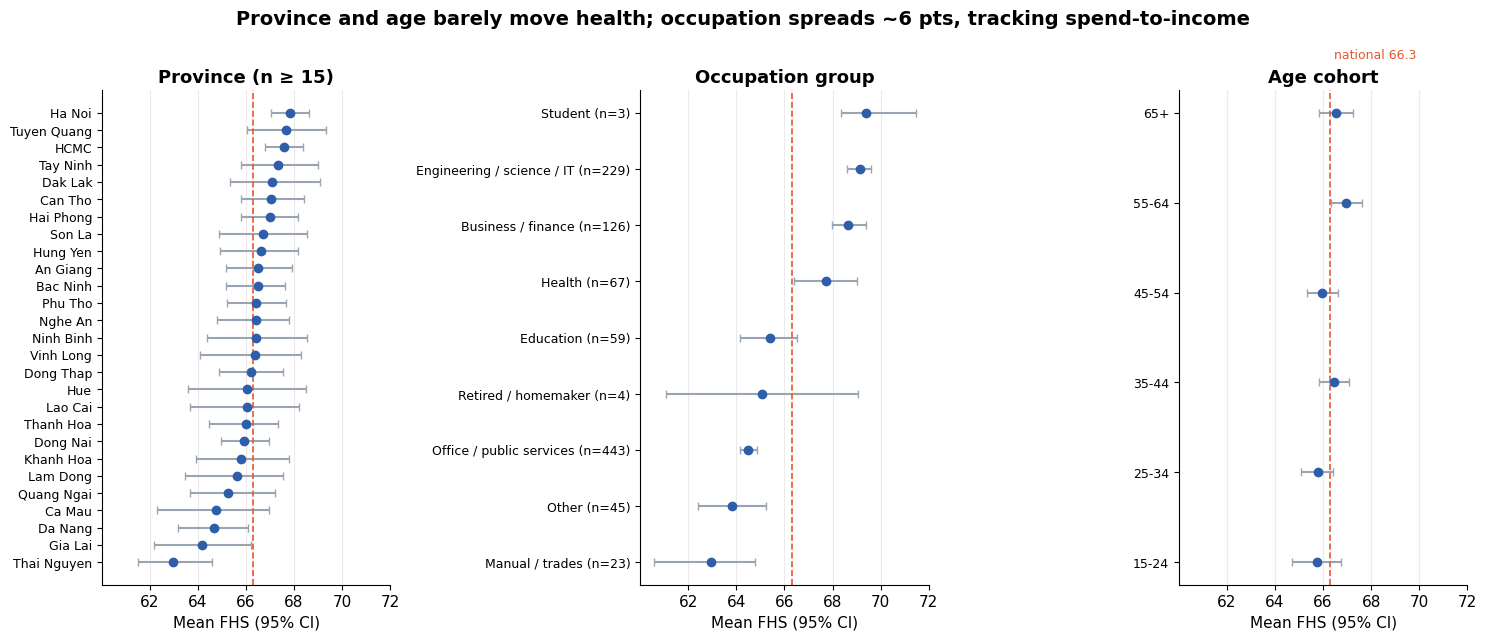

saved t2_demographics.png


In [15]:
h("DEEP Q3c - One chart: province / occupation group / age cohort, mean FHS ± 95% CI")
age_ci = (pd.read_csv("draft/task1_age_ci.csv", index_col=0) if os.path.exists("draft/task1_age_ci.csv") else None)
if age_ci is None:   # P1 chưa chạy -> tự tính
    ac = cons.groupby("cohort", observed=True).fhs
    age_ci = pd.DataFrame({"n": ac.size(), "mean_fhs": ac.mean()})
    age_ci[["ci_lo", "ci_hi"]] = [boot_ci(cons.loc[cons.cohort == k, "fhs"]) for k in age_ci.index]
EN = {"Thành phố Hồ Chí Minh": "HCMC", "Hà Nội": "Ha Noi", "Đồng Nai": "Dong Nai", "Lâm Đồng": "Lam Dong", "Hưng Yên": "Hung Yen",
      "Hải Phòng": "Hai Phong", "Cần Thơ": "Can Tho", "Đà Nẵng": "Da Nang", "Nghệ An": "Nghe An", "Quảng Ngãi": "Quang Ngai",
      "Thanh Hóa": "Thanh Hoa", "Khánh Hòa": "Khanh Hoa", "Gia Lai": "Gia Lai", "Đắk Lắk": "Dak Lak", "An Giang": "An Giang",
      "Tây Ninh": "Tay Ninh", "Đồng Tháp": "Dong Thap", "Vĩnh Long": "Vinh Long", "Ninh Bình": "Ninh Binh", "Phú Thọ": "Phu Tho",
      "Bắc Ninh": "Bac Ninh", "Quảng Ninh": "Quang Ninh", "Huế": "Hue", "Cà Mau": "Ca Mau", "Lào Cai": "Lao Cai",
      "Thái Nguyên": "Thai Nguyen", "Tuyên Quang": "Tuyen Quang", "Quảng Trị": "Quang Tri", "Sơn La": "Son La",
      "Lạng Sơn": "Lang Son", "Cao Bằng": "Cao Bang", "Điện Biên": "Dien Bien", "Lai Châu": "Lai Chau", "Hà Tĩnh": "Ha Tinh"}
panels = [("Province (n ≥ 15)", pv.rename(index=lambda s: EN.get(s, s))[["mean", "ci_lo", "ci_hi"]].rename(columns={"mean": "m"})),
          ("Occupation group", og.sort_values("mean_fhs").rename(index=lambda g: f"{g} (n={og.loc[g, 'n']})")[["mean_fhs", "ci_lo", "ci_hi"]].rename(columns={"mean_fhs": "m"})),
          ("Age cohort", age_ci[["mean_fhs", "ci_lo", "ci_hi"]].rename(columns={"mean_fhs": "m"}))]
fig, axes = plt.subplots(1, 3, figsize=(15, 6.5), sharex=True)
for ax, (t, d) in zip(axes, panels):
    y = np.arange(len(d))
    ax.errorbar(d.m, y, xerr=[d.m - d.ci_lo, d.ci_hi - d.m], fmt="o", color=C["primary"], ecolor=C["muted"], capsize=3)
    ax.axvline(nat, color=C["accent"], ls="--", lw=1.2)
    ax.set_yticks(y, d.index.astype(str), fontsize=9); ax.set_title(t, fontsize=13); ax.grid(axis="y", visible=False)
axes[0].set_xlabel("Mean FHS (95% CI)"); axes[1].set_xlabel("Mean FHS (95% CI)"); axes[2].set_xlabel("Mean FHS (95% CI)")
axes[2].text(nat, len(age_ci) - .4, f" national {nat:.1f}", color=C["accent"], fontsize=9)
fig.suptitle("Province and age barely move health; occupation spreads ~6 pts, tracking spend-to-income",
             fontsize=14, fontweight="bold")
save(fig, "t2_demographics.png")



DEEP transactions - WHEN do stressed months spend? (day-of-week, hour, discretionary share)
state
healthy     40953
stressed    11421

Share of spend by day of week (%):
 state  healthy  stressed
Mon       18.0      21.0
Tue       13.9      12.4
Wed       14.5      11.3
Thu       11.2       9.1
Fri       12.4      12.6
Sat       14.0      12.6
Sun       16.0      21.0
Sun+Mon share: stressed 41.9% vs healthy 34.0%

Share of spend by hour band (%):
 state      healthy  stressed
hour_band                   
00-05         25.1      16.7
06-11         24.7      13.6
12-17         24.8      29.9
18-21         17.1      16.3
22-23          8.3      23.5
-> Biggest over-index for stressed months: 22-23 (+15.2pp of VALUE) -> candidate Spend-Alert timing
Share of TRANSACTION COUNT by hour band (%) — robustness:
 state      healthy  stressed
hour_band                   
00-05         21.4      20.8
06-11         21.5      19.7
12-17         28.4      28.9
18-21         19.1      19.0
22-23     

/tmp/ipykernel_4019/661418300.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  late = t[t.state == "stressed"].groupby(["consumer_id", "transaction_month"]).apply(
/tmp/ipykernel_4019/661418300.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ess = t.groupby("state").apply(lambda d: 100 * (1 - d.loc[d.essential_spending_flag.astype(bool), 'spend_amount_vnd'].sum() / d.spend_amount_vnd.sum()))


Per stressed month: median 22-23h value share 23.0% | months > 20%: 51/95
-> Not MORE late-night transactions (count gap small) but BIGGER late-night tickets, in most stressed months.
Discretionary share (txn-level): {'healthy': 40.5, 'stressed': 71.6}


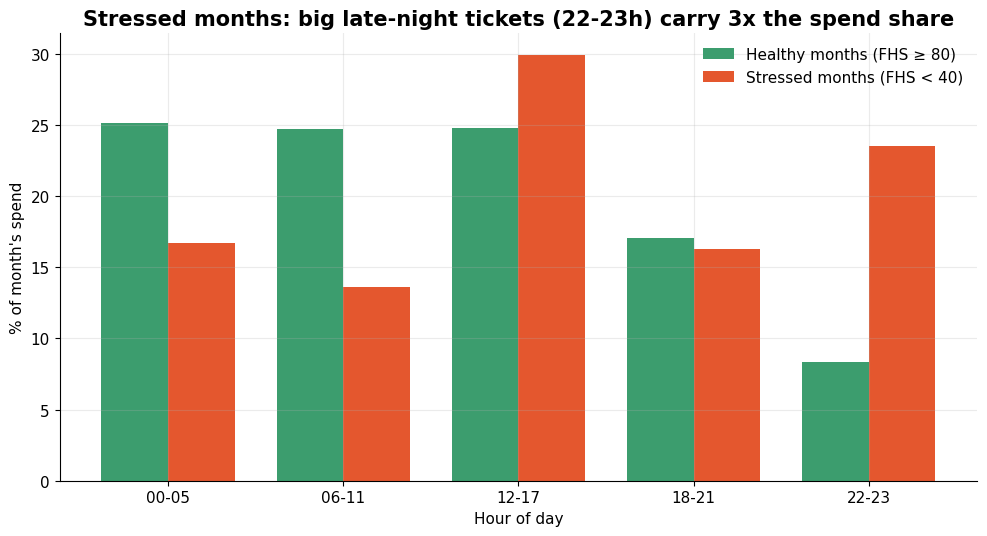

saved t2_timing.png


In [16]:
h("DEEP transactions - WHEN do stressed months spend? (day-of-week, hour, discretionary share)")
tx = pd.read_csv(TXN, usecols=["consumer_id", "transaction_month", "transaction_day_of_week", "transaction_hour",
                               "spend_amount_vnd", "essential_spending_flag"])
mm = mon[["consumer_id", "month", "financial_health_score"]].rename(columns={"month": "transaction_month"})
t = tx.merge(mm, on=["consumer_id", "transaction_month"], how="inner")
t["state"] = np.select([t.financial_health_score < 40, t.financial_health_score >= 80], ["stressed", "healthy"], "mid")
t = t[t.state != "mid"]
print(t.groupby("state").size().rename("transactions").to_string())
dow = pd.crosstab(t.transaction_day_of_week, t.state, values=t.spend_amount_vnd, aggfunc="sum", normalize="columns") * 100
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]   # 0 = Monday (đã kiểm với activity_datetime)
print("\nShare of spend by day of week (%):\n", dow.round(1).to_string())
print(f"Sun+Mon share: stressed {dow.loc[['Sun','Mon'],'stressed'].sum():.1f}% vs healthy {dow.loc[['Sun','Mon'],'healthy'].sum():.1f}%")
t["hour_band"] = pd.cut(t.transaction_hour, [-1, 5, 11, 17, 21, 23], labels=["00-05", "06-11", "12-17", "18-21", "22-23"])
hb = pd.crosstab(t.hour_band, t.state, values=t.spend_amount_vnd, aggfunc="sum", normalize="columns") * 100
print("\nShare of spend by hour band (%):\n", hb.round(1).to_string())
hb["diff_pp"] = hb.stressed - hb.healthy
peak_band = hb.diff_pp.idxmax()
print(f"-> Biggest over-index for stressed months: {peak_band} ({hb.diff_pp.max():+.1f}pp of VALUE) -> candidate Spend-Alert timing")
hc = pd.crosstab(t.hour_band, t.state, normalize="columns") * 100
print("Share of TRANSACTION COUNT by hour band (%) — robustness:\n", hc.round(1).to_string())
late = t[t.state == "stressed"].groupby(["consumer_id", "transaction_month"]).apply(
    lambda d: d.loc[d.transaction_hour >= 22, "spend_amount_vnd"].sum() / d.spend_amount_vnd.sum())
print(f"Per stressed month: median 22-23h value share {100*late.median():.1f}% | months > 20%: {(late > .2).sum()}/{len(late)}")
print("-> Not MORE late-night transactions (count gap small) but BIGGER late-night tickets, in most stressed months.")
ess = t.groupby("state").apply(lambda d: 100 * (1 - d.loc[d.essential_spending_flag.astype(bool), 'spend_amount_vnd'].sum() / d.spend_amount_vnd.sum()))
print("Discretionary share (txn-level):", ess.round(1).to_dict())

fig, ax = plt.subplots(figsize=(10, 5.5))
w = .38; x = np.arange(len(hb))
ax.bar(x - w/2, hb.healthy, w, color=C["good"], label="Healthy months (FHS ≥ 80)")
ax.bar(x + w/2, hb.stressed, w, color=C["accent"], label="Stressed months (FHS < 40)")
ax.set_xticks(x, hb.index.astype(str)); ax.set_ylabel("% of month's spend"); ax.set_xlabel("Hour of day")
ax.set_title("Stressed months: big late-night tickets (22-23h) carry 3x the spend share"); ax.legend(frameon=False)
save(fig, "t2_timing.png")


In [17]:
h("DEEP Q4 - Crossover rule sensitivity (FHS cutoff x engagement percentile)")
stress_all = {}
rows = []
for f in (35, 40, 45):
    st = mon[mon.financial_health_score < f]
    for q in (.70, .75, .80):
        e = mon.engagement_score.quantile(q)
        cx = st[st.engagement_score >= e]
        rows.append((f"FHS<{f}", f"eng>=p{int(q*100)} ({e:.1f})", cx.consumer_id.nunique(), len(cx),
                     round(100 * len(cx) / max(len(st), 1), 1)))
sens = pd.DataFrame(rows, columns=["health", "engagement", "consumers", "months", "%_of_stress_months"])
print(sens.to_string(index=False))



DEEP Q4 - Crossover rule sensitivity (FHS cutoff x engagement percentile)
health      engagement  consumers  months  %_of_stress_months
FHS<35 eng>=p70 (80.6)         24      27                49.1
FHS<35 eng>=p75 (81.4)         23      26                47.3
FHS<35 eng>=p80 (82.3)         22      24                43.6
FHS<40 eng>=p70 (80.6)         44      50                52.6
FHS<40 eng>=p75 (81.4)         43      49                51.6
FHS<40 eng>=p80 (82.3)         41      46                48.4
FHS<45 eng>=p70 (80.6)         91     105                59.7
FHS<45 eng>=p75 (81.4)         89     103                58.5
FHS<45 eng>=p80 (82.3)         86      99                56.2



DEEP Q2 - FHS by spend_to_income quintile (visual version of r = -0.90)
              n    sti     fhs
sti_q                         
Q1 lowest   200  0.488  72.384
Q2          200  0.610  68.433
Q3          199  0.691  65.993
Q4          200  0.774  63.760
Q5 highest  200  0.902  60.942
Q1 -> Q5 FHS drop: 11.4 pts (vs age spread 1.2 pts)


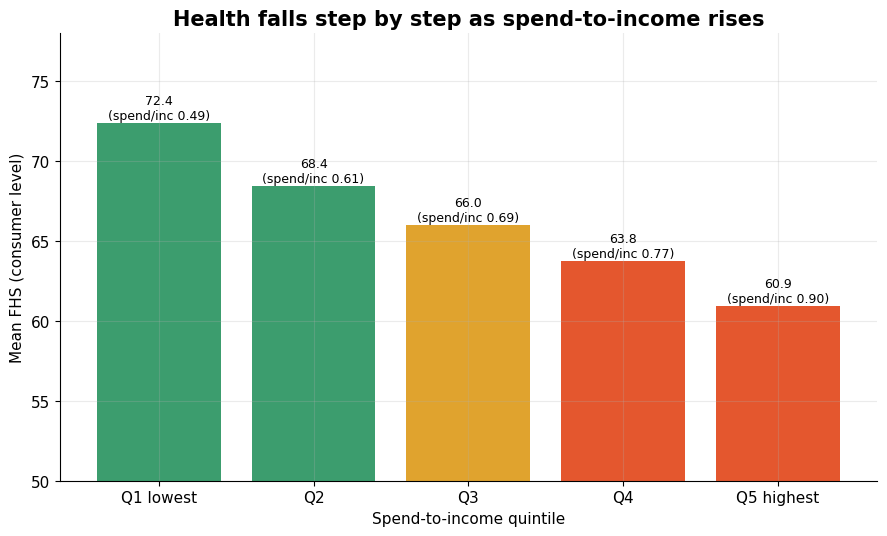

saved t2_sti_quintile.png


In [18]:
h("DEEP Q2 - FHS by spend_to_income quintile (visual version of r = -0.90)")
cons["sti_q"] = pd.qcut(cons.spend_to_income_ratio, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
qq = cons.groupby("sti_q", observed=True).agg(n=("fhs", "size"), sti=("spend_to_income_ratio", "mean"), fhs=("fhs", "mean"))
print(qq.round(3).to_string())
print(f"Q1 -> Q5 FHS drop: {qq.fhs.iloc[0] - qq.fhs.iloc[-1]:.1f} pts "
      f"(vs age spread {cons.groupby('cohort', observed=True).fhs.mean().agg(lambda s: s.max() - s.min()):.1f} pts)")
fig, ax = plt.subplots(figsize=(9, 5.5))
b = ax.bar(qq.index.astype(str), qq.fhs, color=[C["good"], C["good"], C["warn"], C["accent"], C["accent"]])
for r, s in zip(b, qq.sti):
    ax.annotate(f"{r.get_height():.1f}\n(spend/inc {s:.2f})", (r.get_x() + r.get_width()/2, r.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
ax.set_ylim(50, 78); ax.set_ylabel("Mean FHS (consumer level)"); ax.set_xlabel("Spend-to-income quintile")
ax.set_title("Health falls step by step as spend-to-income rises")
save(fig, "t2_sti_quintile.png")


**Findings:**
- Tỉnh: 22/27 tỉnh (≥15 khách) có CI chứa TB toàn quốc 66.3; chênh lớn nhất Thái Nguyên 63.0 ↔ TP.HCM 67.6.
- Nghề (gom 8 nhóm): Engineering/science/IT **69.1** & Business/finance **68.7** vs Office/public **64.5** & Manual **62.9** — chênh **~6 điểm**, lớn hơn tuổi (1.2), nhưng đi kèm spend/income 0.61 vs 0.76–0.79 → nghề ảnh hưởng QUA tỷ lệ chi tiêu, vẫn nhắm theo tỷ lệ.
- Thời điểm: tháng stressed dồn **23.5% giá trị chi tiêu vào 22–23h** (healthy 8.3%); theo SỐ giao dịch chỉ 11.6% vs 9.7% → không phải mua khuya nhiều hơn mà là **món khuya giá trị lớn** (trung vị 23%/tháng, 51/95 tháng >20%). CN+T2 chiếm 41.9% chi tiêu (healthy 34.0%) → gửi Spend Alert tối CN–T2, trước 22h.
- Crossover: luật FHS<40 & eng≥p75 = 43 khách / 51.6% tháng stress; đổi engagement p70–p80 → 41–44 khách (48–53%) → bền; đổi FHS 35/45 thì thay đổi quy mô như mong đợi.
- Quintile spend/income: FHS **72.4 → 60.9** từ Q1 đến Q5 (−11.4 điểm, gấp ~10 lần chênh theo tuổi).

---
# Task 3 — Customer Engagement
### 3.0 Script gốc `draft/task3.py`

In [19]:
%run -i draft/task3.py

Rows(consumer-months)=10,992  consumers=999

Q1 - Engagement score distribution + segment shares
engagement_score (consumer-month):
count    10992.00
mean        77.82
std          6.33
min          9.70
25%         74.80
50%         78.10
75%         81.40
max         99.60
consumer-level mean engagement: 75.40, median 78.17, min 12.80, max 84.32

Segment share (consumer-months):
  Tương tác cao             7,058   64.2%
  Tương tác rất cao         3,824   34.8%
  Tương tác trung bình        100    0.9%
  Tương tác thấp               10    0.1%

Segment share (consumers, modal segment):
  Tương tác cao             740   74.1%
  Tương tác rất cao         169   16.9%
  Tương tác trung bình       80    8.0%
  Tương tác thấp             10    1.0%

Q2 - Channel adoption breakdown + online spend share
Total transactions: 1,852,394
  POS                 1,089,518   58.8%
  QR Payment            367,682   19.8%
  E-commerce            161,670    8.7%
  Mobile App            142,399    7.7%
 

<Figure size 1000x600 with 0 Axes>

### 3.1 Phân tích làm sâu `draft/task3_deep.py`

In [20]:
# Style chung cho chart (giống draft/make_charts.py)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 250, "display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})
C = dict(primary="#2E5EAA", accent="#E4572E", good="#3C9D6E", warn="#E0A32E", muted="#9AA5B1", ink="#22303F")
os.makedirs("outputs/figures", exist_ok=True)
def save(fig, name):
    fig.tight_layout(); fig.savefig(f"outputs/figures/{name}", dpi=150, bbox_inches="tight"); plt.show(); print("saved", name)
SEG_EN = {"Financially Healthy & Highly Engaged": "Healthy & Engaged", "Financially Stretched but Highly Engaged": "Stretched & Engaged",
          "High-Activity Digital Power Users": "Digital Power Users", "Low Engagement & Emerging Digital": "Emerging Digital"}
ENG_EN = {"Tương tác thấp": "Low", "Tương tác trung bình": "Medium", "Tương tác cao": "High", "Tương tác rất cao": "Very high"}



DEEP D1 - Share of consumers in EACH engagement segment (consumer = modal segment)
                    consumers   pct
engagement_segment                 
Low                        10   1.0
Medium                     80   8.0
High                      740  74.1
Very high                 169  16.9


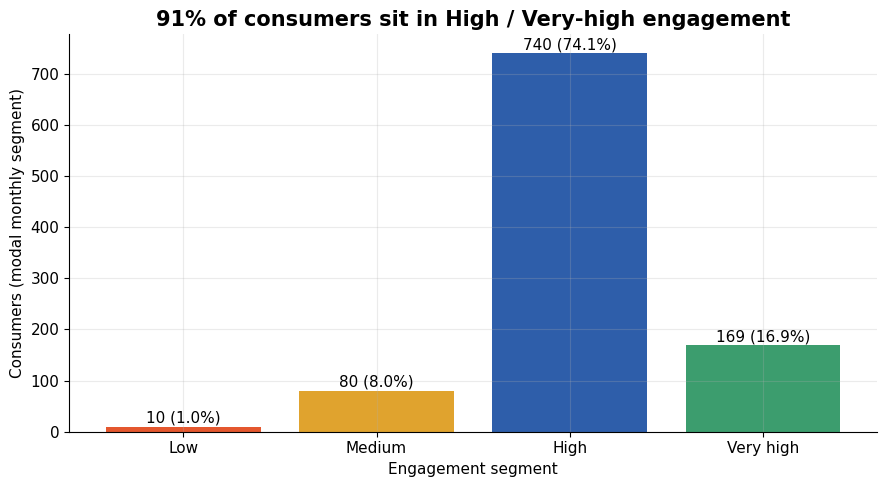

saved t3_segment_share.png


In [21]:
h("DEEP D1 - Share of consumers in EACH engagement segment (consumer = modal segment)")
share = modal.map(ENG_EN).value_counts().reindex(["Low", "Medium", "High", "Very high"])
print(pd.DataFrame({"consumers": share, "pct": (100 * share / N).round(1)}).to_string())
fig, ax = plt.subplots(figsize=(9, 5))
b = ax.bar(share.index, share.values, color=[C["accent"], C["warn"], C["primary"], C["good"]])
for r, v in zip(b, share.values):
    ax.annotate(f"{v} ({100*v/N:.1f}%)", (r.get_x() + r.get_width()/2, v), xytext=(0, 3), textcoords="offset points", ha="center")
ax.set_ylabel("Consumers (modal monthly segment)"); ax.set_xlabel("Engagement segment")
ax.set_title("91% of consumers sit in High / Very-high engagement")
save(fig, "t3_segment_share.png")


In [22]:
h("DEEP D2 - Average online spend share + who uses QR / Mobile (by Task 4 segment)")
print(f"Average online spend share (consumer level): {100*con.online_spend_ratio.mean():.1f}% "
      f"(month level {100*mon.online_spend_ratio.mean():.1f}%)")
seg = pd.read_csv("draft/task4_features.csv", usecols=["consumer_id", "segment"])
tx = pd.read_csv(TXN, usecols=["consumer_id", "transaction_channel", "spend_amount_vnd"]).merge(seg, on="consumer_id")
chs = pd.crosstab(tx.segment.map(SEG_EN), tx.transaction_channel, normalize="index") * 100
chv = pd.crosstab(tx.segment.map(SEG_EN), tx.transaction_channel, values=tx.spend_amount_vnd, aggfunc="sum", normalize="index") * 100
print("Channel share of TRANSACTIONS by segment (%):\n", chs.round(1).to_string())
print("\nChannel share of SPEND by segment (%):\n", chv.round(1).to_string())



DEEP D2 - Average online spend share + who uses QR / Mobile (by Task 4 segment)
Average online spend share (consumer level): 24.7% (month level 21.0%)
Channel share of TRANSACTIONS by segment (%):
 transaction_channel  E-commerce  Mobile App   POS  QR Payment  Recurring Payment
segment                                                                         
Digital Power Users         9.1         8.0  58.2        19.8                4.8
Emerging Digital           23.7        18.6  39.6        12.8                5.2
Healthy & Engaged           8.4         7.5  59.3        19.8                5.0
Stretched & Engaged         8.4         7.5  59.2        19.9                5.0

Channel share of SPEND by segment (%):
 transaction_channel  E-commerce  Mobile App   POS  QR Payment  Recurring Payment
segment                                                                         
Digital Power Users         9.8         7.7  58.3        19.7                4.6
Emerging Digital           34.3


DEEP D3 - Category diversity distribution + is r=+0.94 driven by the small tail?
Consumer-level diversity bins:
 category_diversity
(0.0, 4.0]        27
(4.0, 6.0]        57
(6.0, 8.0]         7
(8.0, 10.0]        0
(10.0, 12.0]       0
(12.0, 13.0]      56
(13.0, 14.01]    852
r(all 999) = +0.938 | r(diversity>=8, n=908) = +0.811 | Spearman(all) = +0.845


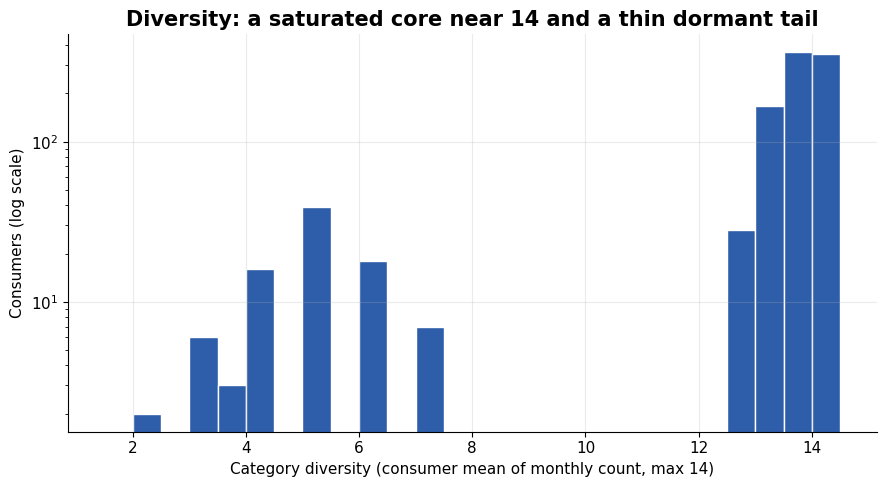

saved t3_diversity_hist.png


In [24]:
h("DEEP D3 - Category diversity distribution + is r=+0.94 driven by the small tail?")
cdv = con.category_diversity
print("Consumer-level diversity bins:\n", pd.cut(cdv, [0, 4, 6, 8, 10, 12, 13, 14.01]).value_counts().sort_index().to_string())
core = con[con.category_diversity >= 8]
print(f"r(all {len(con)}) = {con.category_diversity.corr(con.engagement_score):+.3f} | "
      f"r(diversity>=8, n={len(core)}) = {core.category_diversity.corr(core.engagement_score):+.3f} | "
      f"Spearman(all) = {con.category_diversity.corr(con.engagement_score, method='spearman'):+.3f}")
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cdv, bins=np.arange(1.5, 14.6, 0.5), color=C["primary"], edgecolor="white")
ax.set_yscale("log"); ax.set_xlabel("Category diversity (consumer mean of monthly count, max 14)")
ax.set_ylabel("Consumers (log scale)"); ax.set_title("Diversity: a saturated core near 14 and a thin dormant tail")
save(fig, "t3_diversity_hist.png")



DEEP D4 - Recency x Frequency heatmap (consumer-month, colour = mean engagement)
Mean engagement:
 active_transaction_days    1-5  6-15  16-25  26-29  30-31
transaction_recency_days                                 
0 d                       54.9   NaN   73.0   76.9   79.8
1-3 d                     54.8  66.1   71.3   75.4   76.9
4-10 d                    52.8   NaN   55.7    NaN    NaN
11-30 d                   43.6   NaN    NaN    NaN    NaN

Consumer-months per cell:
 active_transaction_days   1-5  6-15  16-25  26-29  30-31
transaction_recency_days                                
0 d                         7     0   1100   2714   6614
1-3 d                      14     1    273    170     23
4-10 d                     24     0      1      0      0
11-30 d                    51     0      0      0      0


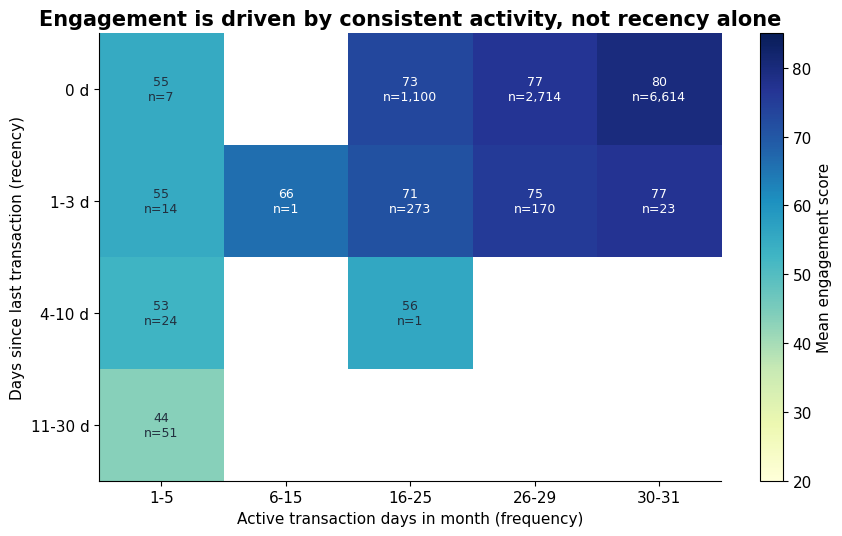

saved t3_recency_frequency.png


In [25]:
h("DEEP D4 - Recency x Frequency heatmap (consumer-month, colour = mean engagement)")
rb = pd.cut(mon.transaction_recency_days, [-0.1, 0, 3, 10, 31], labels=["0 d", "1-3 d", "4-10 d", "11-30 d"])
fb = pd.cut(mon.active_transaction_days, [0, 5, 15, 25, 29, 31], labels=["1-5", "6-15", "16-25", "26-29", "30-31"])
hm = mon.pivot_table(index=rb, columns=fb, values="engagement_score", aggfunc="mean", observed=False)
hn = mon.pivot_table(index=rb, columns=fb, values="engagement_score", aggfunc="size", observed=False)
print("Mean engagement:\n", hm.round(1).to_string()); print("\nConsumer-months per cell:\n", hn.fillna(0).astype(int).to_string())
fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(hm.values, cmap="YlGnBu", vmin=20, vmax=85, aspect="auto")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        n = hn.iloc[i, j]
        if n > 0 and not np.isnan(hm.iloc[i, j]):
            ax.text(j, i, f"{hm.iloc[i, j]:.0f}\nn={int(n):,}", ha="center", va="center", fontsize=9,
                    color="white" if hm.iloc[i, j] > 60 else C["ink"])
ax.set_xticks(range(hm.shape[1]), hm.columns); ax.set_yticks(range(hm.shape[0]), hm.index)
ax.set_xlabel("Active transaction days in month (frequency)"); ax.set_ylabel("Days since last transaction (recency)")
ax.grid(False); fig.colorbar(im, ax=ax, label="Mean engagement score")
ax.set_title("Engagement is driven by consistent activity, not recency alone")
save(fig, "t3_recency_frequency.png")


In [27]:
h("DEEP D5 - Healthy-but-Disengaged cutoff sensitivity (consumer level)")
tab = pd.DataFrame({f"eng<{e}": [int(((con.financial_health_score >= f) & (con.engagement_score < e)).sum()) for f in (65, 70, 75)]
                    for e in (60, 65, 70, 75)}, index=[f"FHS>={f}" for f in (65, 70, 75)])
print(tab.to_string())
gap = con.engagement_score.sort_values()
print("Engagement values around the cutoff (consumer level): largest gap between consecutive consumers in 50-75:",
      gap[(gap > 50) & (gap < 75)].diff().max())
print("Why FHS>=70 & eng<70: the count is flat (25) from eng<60 to eng<70 -> a natural gap; eng<75 jumps as it hits the main body.")



DEEP D5 - Healthy-but-Disengaged cutoff sensitivity (consumer level)
         eng<60  eng<65  eng<70  eng<75
FHS>=65      47      47      48     156
FHS>=70      25      25      25      63
FHS>=75       9       9       9      14
Engagement values around the cutoff (consumer level): largest gap between consecutive consumers in 50-75: 8.19166666666667
Why FHS>=70 & eng<70: the count is flat (25) from eng<60 to eng<70 -> a natural gap; eng<75 jumps as it hits the main body.


In [28]:
h("Chart-choice rationale (for speaker notes)")
for k, v in {
    "t3_segment_share.png": "Bar of 4 ordered categories with counts + % -> reads shares exactly (pie hides small tails).",
    "t3_diversity_hist.png": "Histogram, log y: continuous variable with a huge spike at 14 and a thin tail -> log keeps the tail visible.",
    "t3_recency_frequency.png": "Heatmap: two binned drivers x one outcome -> shows the interaction a pair of scatters would hide.",
    "t3_diversity_vs_engagement.png": "Scatter: two continuous consumer-level variables, correlation is the claim.",
    "t3_channel_mix.png": "Bar by channel: 5 nominal categories, count vs value compared side by side.",
}.items():
    print(f"  {k:<34} {v}")



Chart-choice rationale (for speaker notes)
  t3_segment_share.png               Bar of 4 ordered categories with counts + % -> reads shares exactly (pie hides small tails).
  t3_diversity_hist.png              Histogram, log y: continuous variable with a huge spike at 14 and a thin tail -> log keeps the tail visible.
  t3_recency_frequency.png           Heatmap: two binned drivers x one outcome -> shows the interaction a pair of scatters would hide.
  t3_diversity_vs_engagement.png     Scatter: two continuous consumer-level variables, correlation is the claim.
  t3_channel_mix.png                 Bar by channel: 5 nominal categories, count vs value compared side by side.


**Findings:**
- D1: khách theo segment: Low **1.0%** · Medium **8.0%** · High **74.1%** · Very high **16.9%**.
- D2: online spend share TB **24.7%** (cấp khách). Emerging Digital là nhóm dùng Mobile/E-com: **60.5% giá trị** qua E-com+Mobile (3 segment còn lại ~17%).
- D3: diversity dồn ở 13–14 (908/999), đuôi ≤8 chỉ 91 khách; r bỏ đuôi (diversity ≥8) vẫn **+0.81** (Spearman toàn bộ +0.85) → quan hệ không chỉ do đuôi kéo.
- D4: heatmap: engagement cao nhất ở ô hoạt động 30–31 ngày & recency 0 (79.8, n=6,614); 1–5 ngày hoạt động luôn ≤55 bất kể recency → tần suất đều đặn quan trọng hơn recency.
- D5: FHS≥70 & eng<70 = **25** khách, không đổi khi eng<60/65/70 (khoảng trống tự nhiên), nhảy lên 63 ở eng<75 → cutoff 70 đúng chỗ.

---
# Task 4 — Customer Segmentation
### 4.0 Script gốc `draft/task4.py`

In [29]:
%run -i draft/task4.py


1. PREPROCESSING & FEATURE ENGINEERING
Monthly rows 10,992 -> consumers 999
Clustering features (8): ['financial_health_score', 'spend_to_income_ratio', 'credit_utilization_ratio', 'spending_volatility', 'engagement_score', 'transaction_count', 'discretionary_spend_ratio', 'online_spend_ratio']
Nulls after aggregation: 0

2. MODEL SELECTION - k via elbow + silhouette (k=2..8)
  k      inertia   silhouette
  2       5212.2       0.5574
  3       3720.0       0.2952
  4       3227.8       0.2508
  5       2879.5       0.2318
  6       2669.6       0.2197
  7       2478.2       0.2057
  8       2301.0       0.2170

Silhouette winner overall: k=2 (0.5574)
Chosen k=4 (best silhouette in the interpretable 4-6 range = 0.2508) - k=2/3 over-collapse the personas the case asks for.

3. VALIDATION
Coverage: 999/999 consumers assigned to exactly one segment (PASS)
Final silhouette (k=4): 0.2510
Cluster sizes:
cluster
0    302
1     88
2    351
3    258

4. SEGMENT PROFILES (cluster means, unscale

<Figure size 1000x600 with 0 Axes>

### 4.1 Phân tích làm sâu `draft/task4_deep.py`

In [30]:
# Việc 1 — Preprocessed Dataset: 8 feature thô + 8 feature z-scale + nhãn + nhân khẩu
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(cons[feat])            # cùng scaler với task4.py (fit trên 999 khách)
Z = pd.DataFrame(scaler.transform(cons[feat]), index=cons.index, columns=[f"z_{c}" for c in feat])
ds = cons[feat].join(Z).join(cons[["cluster", "segment", "rule2x2"]]).join(demo)
assert len(ds) == 999 and ds.segment.notna().all() and not ds.isnull().any().any()
ds.to_csv("draft/task4_features.csv")
print(ds.shape, "->", "draft/task4_features.csv")

DICT = {
    "consumer_id": "Mã khách (khoá, nối với 2 file gốc)",
    **{c: f"TB 12 tháng của `{c}` (file consumer-month), trục {FEATURES[c]}" for c in feat},
    **{f"z_{c}": f"`{c}` đã chuẩn hoá z-score (StandardScaler, fit trên 999 khách) — input của k-means" for c in feat},
    "cluster": "Nhãn cụm k-means (k=4, random_state=42, n_init=25)",
    "segment": "Tên segment nghiệp vụ gán theo cực trị của cụm",
    "rule2x2": "Nhãn kiểm chứng 2x2 health x engagement (chia theo median) — không phải mô hình chính",
    "age": "Tuổi (dùng để mô tả, KHÔNG đưa vào phân cụm)", "gender": "Giới tính (mô tả)",
    "occupation": "Nghề (mô tả)", "province": "Tỉnh/thành (mô tả)",
}
with open("draft/data_dictionary_task4.md", "w", encoding="utf-8") as f:
    f.write("# Data dictionary — task4_features.csv\n\n1 dòng / khách (999). Nguồn: consumer_financial_health_engagement_2025.csv, "
            "gộp 12 tháng bằng trung bình. Chỉ dùng tỷ lệ/điểm, không dùng VND tuyệt đối.\n\n| Cột | Ý nghĩa |\n|---|---|\n")
    f.writelines(f"| `{k}` | {v} |\n" for k, v in DICT.items())
print("-> draft/data_dictionary_task4.md")


(999, 23) -> draft/task4_features.csv
-> draft/data_dictionary_task4.md


In [31]:
# Việc 2a — Độ ổn định theo seed: 20 random_state, ARI so với nghiệm gốc (>0.8 = ổn định)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ari
base = cons["cluster"].values
seed_ari = [ari(base, KMeans(K, n_init=10, random_state=s).fit_predict(X)) for s in range(20)]
print(f"ARI theo 20 seed: min {min(seed_ari):.3f} · TB {np.mean(seed_ari):.3f}")


ARI theo 20 seed: min 0.931 · TB 0.988


In [32]:
# Việc 2b — Bootstrap 80% x 50 lần: fit lại trên mẫu con, gán lại cả 999 khách, đo ARI
rng = np.random.default_rng(42)
boot_ari = []
for _ in range(50):
    idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
    boot_ari.append(ari(base, KMeans(K, n_init=10, random_state=42).fit(X[idx]).predict(X)))
print(f"ARI bootstrap 80%: TB {np.mean(boot_ari):.3f} · 5th pct {np.percentile(boot_ari, 5):.3f}")


ARI bootstrap 80%: TB 0.911 · 5th pct 0.843


In [33]:
# Việc 2c — So với GMM (gán mềm): ARI k-means vs GMM + % khách 'ở biên' (xác suất cao nhất < 0.6)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(K, covariance_type="full", n_init=5, random_state=42).fit(X)
g_lab, g_p = gmm.predict(X), gmm.predict_proba(X).max(1)
print(f"ARI k-means vs GMM: {ari(base, g_lab):.3f}")
print(f"Khách ở biên (p<0.6): {(g_p < 0.6).sum()} ({(g_p < 0.6).mean():.1%})")
print(pd.crosstab(cons["segment"], g_lab, rownames=["k-means"], colnames=["GMM"]))


ARI k-means vs GMM: 0.259
Khách ở biên (p<0.6): 34 (3.4%)
GMM                                         0    1   2    3
k-means                                                    
Financially Healthy & Highly Engaged      101  104   1  145
Financially Stretched but Highly Engaged   42   67   2  191
High-Activity Digital Power Users         220   19   0   19
Low Engagement & Emerging Digital           0    0  88    0


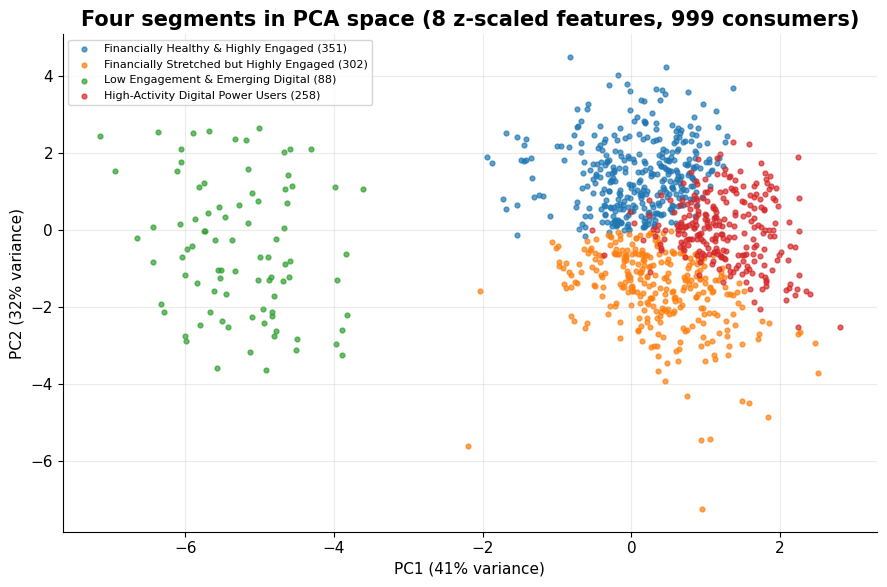

In [34]:
# Việc 2d — PCA 2D tô màu segment (chart cho slide mới)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(2, random_state=42).fit(X); P2 = pca.transform(X)
fig, ax = plt.subplots(figsize=(9, 6))
for s in cons["segment"].unique():
    m = (cons["segment"] == s).values
    ax.scatter(P2[m, 0], P2[m, 1], s=12, alpha=.7, label=f"{s} ({m.sum()})")
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)",
       title="Four segments in PCA space (8 z-scaled features, 999 consumers)")
ax.legend(fontsize=8, loc="best"); fig.tight_layout()
fig.savefig("outputs/figures/t4_pca.png", dpi=150); plt.show()


In [35]:
# Việc 3 — Dịch chuyển segment theo tháng: gán MỖI consumer-month vào centroid gần nhất (cùng scaler)
mon = mon.sort_values(["consumer_id", "analysis_month"])
name = dict(zip(cons["cluster"], cons["segment"]))
mon["seg"] = pd.Series(km.predict(scaler.transform(mon[feat])), index=mon.index).map(name)
mon["seg_next"] = mon.groupby("consumer_id")["seg"].shift(-1)
tr = mon.dropna(subset=["seg_next"])
print("Ma trận chuyển tháng t -> t+1 (% theo hàng):")
print((100 * pd.crosstab(tr.seg, tr.seg_next, normalize="index")).round(1))
H, S = "Financially Healthy & Highly Engaged", "Financially Stretched but Highly Engaged"
mon["m"] = pd.to_datetime(mon["analysis_month"]).dt.month
h = tr.assign(m=mon.loc[tr.index, "m"]).query("seg == @H")
slide = h.groupby("m")["seg_next"].apply(lambda s: (s == S).mean() * 100).round(1)
print("\n% tháng Healthy trượt sang Stretched ở tháng kế tiếp, theo tháng xuất phát:")
print(slide.to_string())
print(f"-> TB cả năm {slide.mean():.1f}% | T10->T11 {slide.get(10, np.nan)}% | T11->T12 {slide.get(11, np.nan)}%")


Ma trận chuyển tháng t -> t+1 (% theo hàng):
seg_next                                  Financially Healthy & Highly Engaged  Financially Stretched but Highly Engaged  High-Activity Digital Power Users  Low Engagement & Emerging Digital
seg                                                                                                                                                                                           
Financially Healthy & Highly Engaged                                      59.5                                      23.0                               17.6                                0.0
Financially Stretched but Highly Engaged                                  33.8                                      58.4                                7.8                                0.0
High-Activity Digital Power Users                                         39.0                                      17.2                               43.8                                0.0


In [36]:
# Việc 4 — Hồ sơ nhân khẩu từng segment (kiểm tra segment có trùng nhân khẩu học không)
bins = [14, 17, 24, 34, 44, 54, 64, 120]
labs = ["15-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]   # giữ 7 khách 15–17 tuổi
ds["age_grp"] = pd.cut(ds.age, bins, labels=labs)
print("Tuổi TB:\n", ds.groupby("segment").age.agg(["mean", "median"]).round(1))
print("\n% giới tính:\n", (100 * pd.crosstab(ds.segment, ds.gender, normalize="index")).round(1))
print("\n% nhóm tuổi:\n", (100 * pd.crosstab(ds.segment, ds.age_grp, normalize="index")).round(1))
print("\nTop 3 tỉnh mỗi segment:")
for s, g in ds.groupby("segment"):
    print(f"  {s}: " + ", ".join(f"{p} {v:.0%}" for p, v in g.province.value_counts(normalize=True).head(3).items()))
from scipy.stats import chi2_contingency
for col in ["gender", "age_grp"]:
    p = chi2_contingency(pd.crosstab(ds.segment, ds[col]))[1]
    print(f"Chi-square segment x {col}: p = {p:.3f}  ({'có liên quan' if p < .05 else 'không khác biệt có ý nghĩa'})")


Tuổi TB:
                                           mean  median
segment                                               
Financially Healthy & Highly Engaged      52.7    53.0
Financially Stretched but Highly Engaged  50.6    50.0
High-Activity Digital Power Users         43.2    41.0
Low Engagement & Emerging Digital         57.9    59.0

% giới tính:
 gender                                     Nam    Nữ
segment                                             
Financially Healthy & Highly Engaged      49.9  50.1
Financially Stretched but Highly Engaged  56.6  43.4
High-Activity Digital Power Users         39.5  60.5
Low Engagement & Emerging Digital         52.3  47.7

% nhóm tuổi:
 age_grp                                   15-17  18-24  25-34  35-44  45-54  55-64   65+
segment                                                                                 
Financially Healthy & Highly Engaged        0.3    2.8   16.5   15.1   18.5   22.8  23.9
Financially Stretched but Highly Engaged    0

In [37]:
# Việc 5 — Ánh xạ sang 6 tên gợi ý của đề: 2x2 rule + 2 nhóm đề gợi ý nằm ở đâu
print((pd.crosstab(cons["segment"], cons["rule2x2"], margins=True)))
ess = cons["discretionary_spend_ratio"] < 0.40            # 'Essential-Spend-Focused': essential > 60%
print(f"\nEssential-focused (discretionary < 40%): {ess.sum()} khách")
print(cons.loc[ess, "segment"].value_counts())
hd = (cons.financial_health_score >= 70) & (cons.engagement_score < 70)   # cutoff của P3 (kiểm lại với P3)
print(f"\nHealthy but Disengaged (FHS>=70 & engagement<70): {hd.sum()} khách")
print(cons.loc[hd, "segment"].value_counts())


rule2x2                                   Healthy+Disengaged  Healthy+Engaged  Stretched+Engaged  Vulnerable+Disengaged  All
segment                                                                                                                     
Financially Healthy & Highly Engaged                     182              162                  2                      5  351
Financially Stretched but Highly Engaged                  26                3                110                    163  302
High-Activity Digital Power Users                         11               78                148                     21  258
Low Engagement & Emerging Digital                         39                0                  0                     49   88
All                                                      258              243                260                    238  999

Essential-focused (discretionary < 40%): 4 khách
segment
Financially Stretched but Highly Engaged    3
Financially Healthy &

**Findings:**
- Ổn định theo seed: ARI TB **0.988** (min 0.931) · bootstrap 80%: ARI TB **0.911** → nghiệm k=4 ổn định.
- GMM: ARI với k-means **0.259**; chỉ **3.4%** khách ở biên. Emerging Digital (88) trùng 100%; 3 segment lớn là một dải liên tục (thấy rõ trên PCA) → nói thẳng trong Limitations.
- Dịch chuyển: tháng Healthy trượt sang Stretched tháng sau TB **23.3%**, nhưng **T11→T12 = 72.4%** → bằng chứng cho Planning Reminder trước tháng 12.
- Nhân khẩu: Power Users trẻ hơn (43.2 tuổi vs 50.6–57.9) và 60.5% nữ; chi-square p<0.01 → segment CÓ tương quan nhân khẩu dù không phân cụm theo nhân khẩu → kích hoạt theo hành vi.
- Tên gợi ý của đề: Essential-Spend-Focused chỉ **4** khách → không thành cụm; Healthy-but-Disengaged **25** khách, 24 nằm trong Emerging Digital.

---
# Task 5 — Business Recommendations
### 5.0 Script gốc `draft/task5.py`

In [38]:
%run -i draft/task5.py

Base: 999 consumers | 10992 consumer-months

=== T4 segments (consumer level) ===
  Financially Healthy & Highly Engaged: 351 (35.1%)
  Financially Stretched but Highly Engaged: 302 (30.2%)
  High-Activity Digital Power Users: 258 (25.8%)
  Low Engagement & Emerging Digital: 88 (8.8%)

=== T2 crossover (Stressed & Engaged), month grain ===
  engagement p75 = 81.40
  stressed consumer-months (FHS<40): 95 (70 distinct)
  crossover consumer-months: 49
  crossover distinct consumers: 43 (4.3%)
  share of all stress months: 52%

=== T3 dormant good (FHS>=70 & eng<70), consumer level ===
  25 (2.5%)

=== T3 distress tail (FHS<70 & eng<70), consumer level ===
  67 (6.7%)

=== Age 25-34 cohort ===
  177 (17.7%)

=== Fairness: Stretched segment vs base (age/gender/top provinces) ===
  Stretched n=302  mean age 50.6 vs base 50.1
  gender mix stretched: {'Nam': 0.566, 'Nữ': 0.434}
  gender mix base:      {'Nữ': 0.506, 'Nam': 0.494}
  province over/under-representation (stretched share / base shar

<Figure size 1000x600 with 0 Axes>

### 5.1 Phân tích làm sâu `draft/task5_deep.py`

In [39]:
# Style chung cho chart (giống draft/make_charts.py)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 250, "display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})
C = dict(primary="#2E5EAA", accent="#E4572E", good="#3C9D6E", warn="#E0A32E", muted="#9AA5B1", ink="#22303F")
os.makedirs("outputs/figures", exist_ok=True)
def save(fig, name):
    fig.tight_layout(); fig.savefig(f"outputs/figures/{name}", dpi=150, bbox_inches="tight"); plt.show(); print("saved", name)
def h(t): print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)



Impact scenario - what if Budgeting trims spend-to-income? (illustrative, NOT a forecast)
Month-level fit: FHS = 84.1 -25.33 x spend_to_income  (r = -0.90, n = 10,992)
spend/income change (Stretched 302)  Stretched mean FHS  stress months (all 999)  consumers with a stress month
                              Today                62.7                       95                             70
                                -5%                63.7                       80                             59
                               -10%                64.8                       65                             51
                               -15%                65.9                       49                             40
  -5%: stress months 95 -> 80 (-16%)
  -10%: stress months 95 -> 65 (-32%)
Caveat: FHS is partly built from spend fields -> slope is mechanical, directional only; validate with an A/B test.


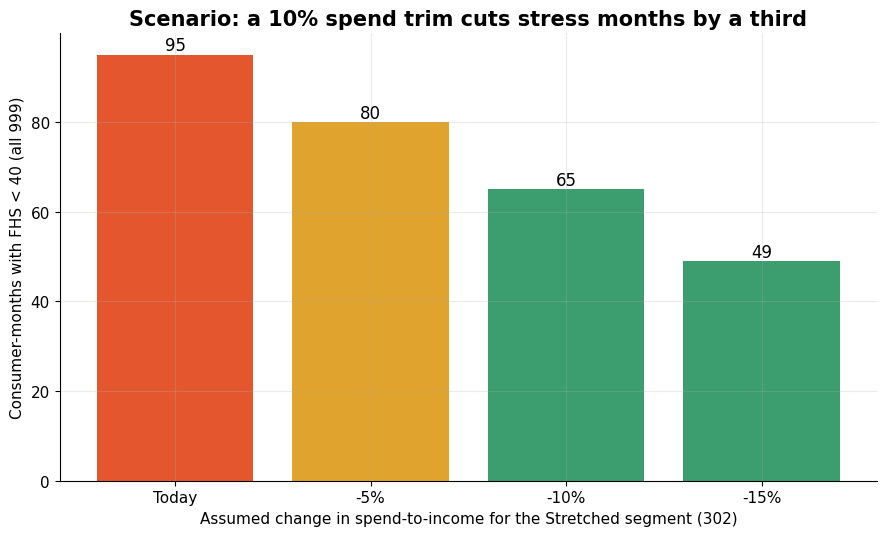

saved t5_impact_scenario.png


In [40]:
h("Impact scenario - what if Budgeting trims spend-to-income? (illustrative, NOT a forecast)")
b, a = np.polyfit(m.spend_to_income_ratio, m.financial_health_score, 1)
r = m.spend_to_income_ratio.corr(m.financial_health_score)
print(f"Month-level fit: FHS = {a:.1f} {b:+.2f} x spend_to_income  (r = {r:.2f}, n = {len(m):,})")
stretched_ids = set(f.loc[f.segment == "Financially Stretched but Highly Engaged", "consumer_id"])
ms = m[m.consumer_id.isin(stretched_ids)]
rows = []
for cut in (0, .05, .10, .15):
    fhs_new = m.financial_health_score - b * m.spend_to_income_ratio * cut * m.consumer_id.isin(stretched_ids)
    st_new = fhs_new < 40
    rows.append(("Today" if cut == 0 else f"-{int(cut*100)}%", round(float((ms.financial_health_score - b * ms.spend_to_income_ratio * cut).mean()), 1),
                 int(st_new.sum()), int(m.loc[st_new, "consumer_id"].nunique())))
sc = pd.DataFrame(rows, columns=["spend/income change (Stretched 302)", "Stretched mean FHS", "stress months (all 999)", "consumers with a stress month"])
print(sc.to_string(index=False))
base_st = sc.iloc[0, 2]
for i in (1, 2):
    print(f"  {sc.iloc[i,0]}: stress months {base_st} -> {sc.iloc[i,2]} ({100*(sc.iloc[i,2]/base_st-1):+.0f}%)")
print("Caveat: FHS is partly built from spend fields -> slope is mechanical, directional only; validate with an A/B test.")

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(sc.iloc[:, 0], sc.iloc[:, 2], color=[C["accent"], C["warn"], C["good"], C["good"]])
for rct, v in zip(bars, sc.iloc[:, 2]):
    ax.annotate(f"{v}", (rct.get_x() + rct.get_width()/2, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=12)
ax.set_xlabel("Assumed change in spend-to-income for the Stretched segment (302)")
ax.set_ylabel("Consumer-months with FHS < 40 (all 999)")
ax.set_title("Scenario: a 10% spend trim cuts stress months by a third")
save(fig, "t5_impact_scenario.png")


In [41]:
h("Measurement plan - one KPI per tool, each tested with a randomised holdout")
kpi = pd.DataFrame([
    ("Budgeting tool", "Stretched & Engaged (302)", "spend-to-income ratio; % months FHS<40", "10% random holdout, 3 months"),
    ("Spend alerts", "Crossover (43; 52% of stress months)", "stress months per consumer; discretionary share in alert window", "alert vs no-alert, 2 months"),
    ("Planning reminders", "Power Users (258) + Healthy (351) before Dec", "Nov->Dec slide Healthy->Stretched (base 72.4%)", "reminder in Nov vs holdout"),
    ("Financial education", "Distress tail (67)", "module completion; essential share next month", "opt-in cohort vs matched"),
    ("Digital nudges", "Emerging Digital (88)", "active days / month; category diversity", "nudge vs holdout, 2 months"),
    ("Product suggestions", "Healthy & Engaged (351)", "opt-in savings/loyalty uptake; FHS stable", "offer vs holdout; guardrail: FHS never used for credit"),
], columns=["Tool", "Target", "KPI", "Test design"])
print(kpi.to_string(index=False))



Measurement plan - one KPI per tool, each tested with a randomised holdout
               Tool                                       Target                                                             KPI                                            Test design
     Budgeting tool                    Stretched & Engaged (302)                          spend-to-income ratio; % months FHS<40                           10% random holdout, 3 months
       Spend alerts         Crossover (43; 52% of stress months) stress months per consumer; discretionary share in alert window                            alert vs no-alert, 2 months
 Planning reminders Power Users (258) + Healthy (351) before Dec                  Nov->Dec slide Healthy->Stretched (base 72.4%)                             reminder in Nov vs holdout
Financial education                           Distress tail (67)                   module completion; essential share next month                               opt-in cohort vs matched
    

In [42]:
h("30/60/90-day roadmap")
for k, v in {"Days 0-30": "Launch Budgeting (302) + Spend Alerts (43), timed Sun-Mon & 22-23h (Task 2 timing); set holdouts",
             "Days 31-60": "Planning Reminders before December (Nov->Dec slide 72.4%); Digital Nudges (88)",
             "Days 61-90": "Education (67) + opt-in Product suggestions (351); read A/B results, keep what moves the KPI"}.items():
    print(f"  {k:<11} {v}")



30/60/90-day roadmap
  Days 0-30   Launch Budgeting (302) + Spend Alerts (43), timed Sun-Mon & 22-23h (Task 2 timing); set holdouts
  Days 31-60  Planning Reminders before December (Nov->Dec slide 72.4%); Digital Nudges (88)
  Days 61-90  Education (67) + opt-in Product suggestions (351); read A/B results, keep what moves the KPI


**Findings:**
- Kịch bản (giả định): FHS = 84.1 − 25.3 × spend/income (r −0.90). Stretched (302) giảm spend/income **5% → tháng stress 95→80 (−16%)**, **10% → 65 (−32%)**, 15% → 49.
- KPI + A/B holdout cho cả 6 công cụ; lộ trình 30/60/90 ngày: Budgeting + Alerts (tối CN–T2) → Reminders trước T12 + Nudges → Education + Products.
- Input đồng đội đã đưa vào: giờ gửi alert (P2), 72.4% trượt T11→T12 (P4), Emerging Digital dùng Mobile/E-com 60.5% giá trị (P3).

---
# Chart cho deck
Vẽ lại 16 chart gốc (`draft/make_charts.py`) — cùng với chart của các phần làm sâu ở trên là đủ bộ hình của deck 22 slide.

In [43]:
%run draft/make_charts.py

loading data...
wrote outputs/figures/t1_monthly_spend.png
wrote outputs/figures/t1_essential_discretionary.png
wrote outputs/figures/t1_category_ticket.png
wrote outputs/figures/t1_age_cohort.png
wrote outputs/figures/t2_fhs_distribution.png
wrote outputs/figures/t2_low_health_drivers.png
wrote outputs/figures/t2_crossover.png
wrote outputs/figures/t3_engagement_dist.png
wrote outputs/figures/t3_channel_mix.png
wrote outputs/figures/t3_diversity_vs_engagement.png
wrote outputs/figures/t3_health_vs_engagement_quadrant.png
wrote outputs/figures/t4_segment_sizes.png
wrote outputs/figures/t4_segment_profiles.png
wrote outputs/figures/t4_silhouette.png
wrote outputs/figures/t5_priority_ranking.png
wrote outputs/figures/t5_target_sizes.png

DONE. Files in outputs/figures


In [44]:
# Tải toàn bộ chart về máy
import shutil
from google.colab import files
shutil.make_archive('/content/yappers_figures', 'zip', 'outputs/figures')
files.download('/content/yappers_figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>